# Day 6 - Hyperparameter Tuning with GridSearchCV

Remote Internship Task

This notebook continues the Student Performance Prediction project.
So far we have:
- Day 4: Trained a single Logistic Regression model
- Day 5: Compared Logistic Regression vs a default Decision Tree

Today, we go one step further:
1. Clean the data and select features (same as before)
2. Scale the features
3. Split into training/testing sets
4. Use **GridSearchCV** to search for the best Decision Tree hyperparameters
5. Compare the tuned Decision Tree against BOTH Day 5 models
   (Logistic Regression and the default/untuned Decision Tree)
6. Evaluate all three using Accuracy, Precision, Recall, F1 Score, and ROC-AUC
7. Visualize the comparison


## 1. Data Cleaning

Same as Day 3/4/5: attendance above 100% is invalid (treated as missing),
and missing numeric values are filled with the column median.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

df = pd.read_csv("students.csv")

df.loc[df["Attendance"] > 100, "Attendance"] = np.nan
numeric_columns = ["Age", "Attendance", "Assignment_Score", "Midterm_Score", "Final_Score"]
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Student_Name        0
Age                 0
Gender              0
Course              0
Attendance          0
Assignment_Score    0
Midterm_Score       0
Final_Score         0
dtype: int64


## 2. Feature Selection

Same target as Day 4/5: a weighted **Overall Score**
(20% Assignment, 30% Midterm, 50% Final), Pass if Overall Score ≥ 40.

Our selected features are the same four we've used throughout this project:
Attendance, Assignment Score, Midterm Score, Final Score. We keep the same
feature set here so that today's comparison is fair against Day 5's models —
changing features AND tuning hyperparameters at the same time would make it
hard to tell which change caused any difference in results.

In [2]:
df["Overall_Score"] = (
    df["Assignment_Score"] * 0.20 +
    df["Midterm_Score"] * 0.30 +
    df["Final_Score"] * 0.50
)
df["Result"] = np.where(df["Overall_Score"] >= 40, 1, 0)  # 1 = Pass, 0 = Fail

features = ["Attendance", "Assignment_Score", "Midterm_Score", "Final_Score"]
X = df[features]
y = df["Result"]

print("Pass/Fail counts:")
print(df["Result"].value_counts())

Pass/Fail counts:
Result
1    26
0     4
Name: count, dtype: int64


## 3. Train-Test Split

Same split as before: 80% training, 20% testing, stratified so both sets
keep a similar Pass/Fail proportion.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} students, class counts: {y_train.value_counts().to_dict()}")
print(f"Testing set : {len(X_test)} students, class counts: {y_test.value_counts().to_dict()}")

Training set: 24 students, class counts: {1: 21, 0: 3}
Testing set : 6 students, class counts: {1: 5, 0: 1}


## 4. Feature Scaling

We use `StandardScaler` to scale our features so they all have a mean of 0
and a standard deviation of 1. This mainly matters for Logistic Regression
(which is sensitive to feature scale), and doesn't hurt Decision Trees
(which don't strictly need scaling, since they split on thresholds rather
than distances). We fit the scaler ONLY on the training data, then use that
same fitted scaler to transform the test data — this avoids leaking any
information from the test set into training.

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First 3 rows of scaled training features:")
print(X_train_scaled[:3])

First 3 rows of scaled training features:
[[-1.35238576 -0.53690486 -0.61459252  0.40583188]
 [ 0.32775467  0.85416682  0.89825061  1.529674  ]
 [-1.42875578  0.48809532  0.         -0.26014864]]


## 5. Rebuild Day 5's Baseline Models

To compare fairly, we retrain the same two Day 5 models here (same random
state, same split), so all three models in today's comparison come from
the exact same train/test split.

In [5]:
# Baseline 1: Logistic Regression (same as Day 4/5)
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
log_proba = log_model.predict_proba(X_test)[:, 1]

# Baseline 2: Default (untuned) Decision Tree (same as Day 5)
tree_baseline = DecisionTreeClassifier(random_state=42)
tree_baseline.fit(X_train, y_train)
tree_baseline_pred = tree_baseline.predict(X_test)
tree_baseline_proba = tree_baseline.predict_proba(X_test)[:, 1]

print("Baseline models retrained.")

Baseline models retrained.


## 6. Hyperparameter Tuning with GridSearchCV

We tune the Decision Tree because Day 5 showed it underperforming Logistic
Regression, using only 2 splits by default and ignoring 2 of our 4 features.
GridSearchCV will systematically try different combinations of settings and
pick the combination that performs best, based on cross-validation.

**Parameters we search over:**
- `max_depth` — how deep the tree is allowed to grow
- `min_samples_split` — minimum samples needed to split a node
- `min_samples_leaf` — minimum samples allowed in a leaf (end node)
- `criterion` — how the tree measures the quality of a split (gini vs entropy)

**A note on cross-validation folds:** GridSearchCV normally uses 5-fold
cross-validation by default. But our training set only has 24 students,
and only 3 of them are "Fail" cases — with 5 folds, some folds could end
up with zero Fail examples, which would break stratification. So we use
**3-fold** stratified cross-validation instead, which is more appropriate
for a dataset this small.

We optimize for **F1 Score** rather than Accuracy, since our classes are
imbalanced (as we saw in Day 5) and F1 gives a more balanced picture.

In [6]:
param_grid = {
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_split": [2, 3, 4, 5],
    "min_samples_leaf": [1, 2, 3],
    "criterion": ["gini", "entropy"]
}

# 3-fold instead of the default 5-fold, because our training set is small
# and has very few "Fail" examples
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters found:")
print(grid_search.best_params_)
print(f"\nBest cross-validation F1 score: {grid_search.best_score_:.3f}")

Best parameters found:
{'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best cross-validation F1 score: 0.897


In [7]:
# Use the best model found by GridSearchCV
tuned_tree = grid_search.best_estimator_

tuned_pred = tuned_tree.predict(X_test_scaled)
tuned_proba = tuned_tree.predict_proba(X_test_scaled)[:, 1]

print("Tuned Decision Tree predictions:", tuned_pred)
print("Actual values:                  ", y_test.values)

Tuned Decision Tree predictions: [0 1 1 1 0 1]
Actual values:                   [0 1 1 1 1 1]


## 7. Evaluate All Three Models

We now evaluate:
1. Logistic Regression (Day 4/5 baseline)
2. Decision Tree - default settings (Day 5 baseline)
3. Decision Tree - tuned with GridSearchCV (Day 6)

using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

In [8]:
def evaluate_model(y_true, y_pred, y_proba, name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_proba)

    print(f"===== {name} =====")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1 Score : {f1:.3f}")
    print(f"ROC-AUC  : {auc:.3f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()

    return acc, prec, rec, f1, auc

log_scores = evaluate_model(y_test, log_pred, log_proba, "Logistic Regression")

===== Logistic Regression =====
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1 Score : 1.000
ROC-AUC  : 1.000

Confusion Matrix:
[[1 0]
 [0 5]]



In [9]:
tree_baseline_scores = evaluate_model(
    y_test, tree_baseline_pred, tree_baseline_proba, "Decision Tree (Default/Untuned)"
)

===== Decision Tree (Default/Untuned) =====
Accuracy : 0.833
Precision: 1.000
Recall   : 0.800
F1 Score : 0.889
ROC-AUC  : 0.900

Confusion Matrix:
[[1 0]
 [1 4]]



In [10]:
tuned_scores = evaluate_model(
    y_test, tuned_pred, tuned_proba, "Decision Tree (Tuned with GridSearchCV)"
)

===== Decision Tree (Tuned with GridSearchCV) =====
Accuracy : 0.833
Precision: 1.000
Recall   : 0.800
F1 Score : 0.889
ROC-AUC  : 0.900

Confusion Matrix:
[[1 0]
 [1 4]]



## 8. Comparison Table

In [11]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree (Default)",
        "Decision Tree (Tuned)"
    ],
    "Accuracy": [log_scores[0], tree_baseline_scores[0], tuned_scores[0]],
    "Precision": [log_scores[1], tree_baseline_scores[1], tuned_scores[1]],
    "Recall": [log_scores[2], tree_baseline_scores[2], tuned_scores[2]],
    "F1 Score": [log_scores[3], tree_baseline_scores[3], tuned_scores[3]],
    "ROC-AUC": [log_scores[4], tree_baseline_scores[4], tuned_scores[4]],
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,1.000000,1.0,1.0,1.000000,1.0
1,Decision Tree (Default),0.833333,1.0,0.8,0.888889,0.9
2,Decision Tree (Tuned),0.833333,1.0,0.8,0.888889,0.9


## 9. Visualizations

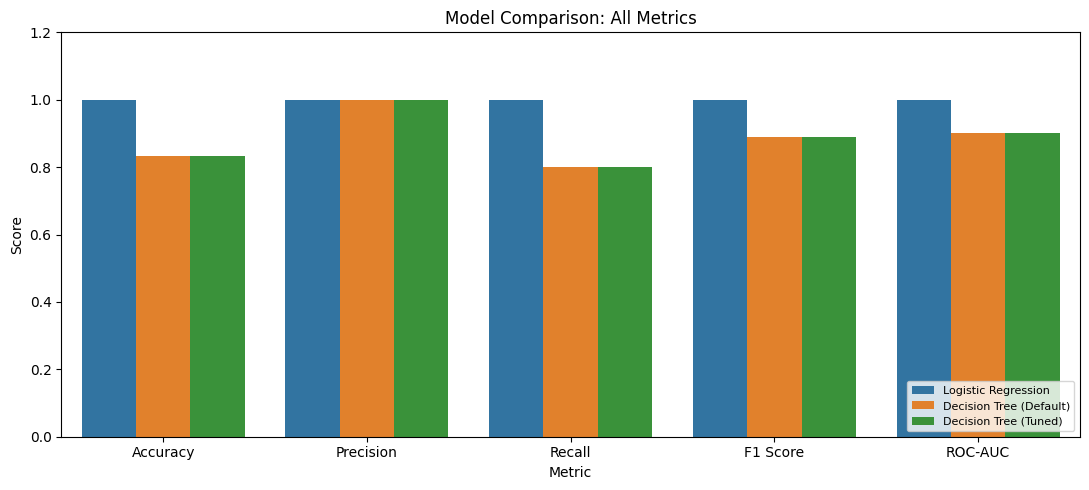

In [12]:
# Visualization 1: Metric comparison across all 3 models
metrics_melted = comparison_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(11, 5))
sns.barplot(data=metrics_melted, x="Metric", y="Score", hue="Model")
plt.title("Model Comparison: All Metrics")
plt.ylim(0, 1.2)
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("chart1_all_metrics_comparison.png")
plt.show()

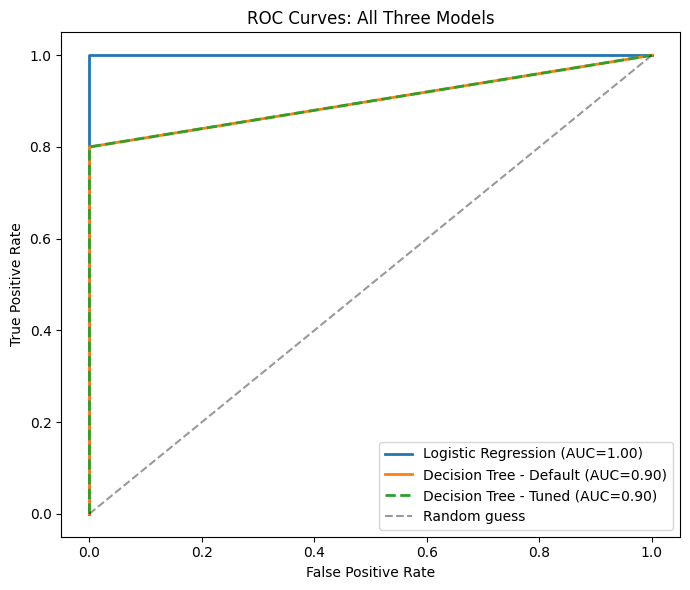

In [13]:
# Visualization 2: ROC Curves for all 3 models
plt.figure(figsize=(7, 6))

fpr_log, tpr_log, _ = roc_curve(y_test, log_proba)
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_baseline_proba)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, tuned_proba)

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC={log_scores[4]:.2f})", linewidth=2)
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree - Default (AUC={tree_baseline_scores[4]:.2f})", linewidth=2)
# Tuned tree is plotted as a dashed line on top, since its predictions may be
# identical to the default tree on this small dataset (the lines can overlap)
plt.plot(fpr_tuned, tpr_tuned, label=f"Decision Tree - Tuned (AUC={tuned_scores[4]:.2f})",
          linewidth=2, linestyle="--")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: All Three Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("chart2_roc_curves.png")
plt.show()

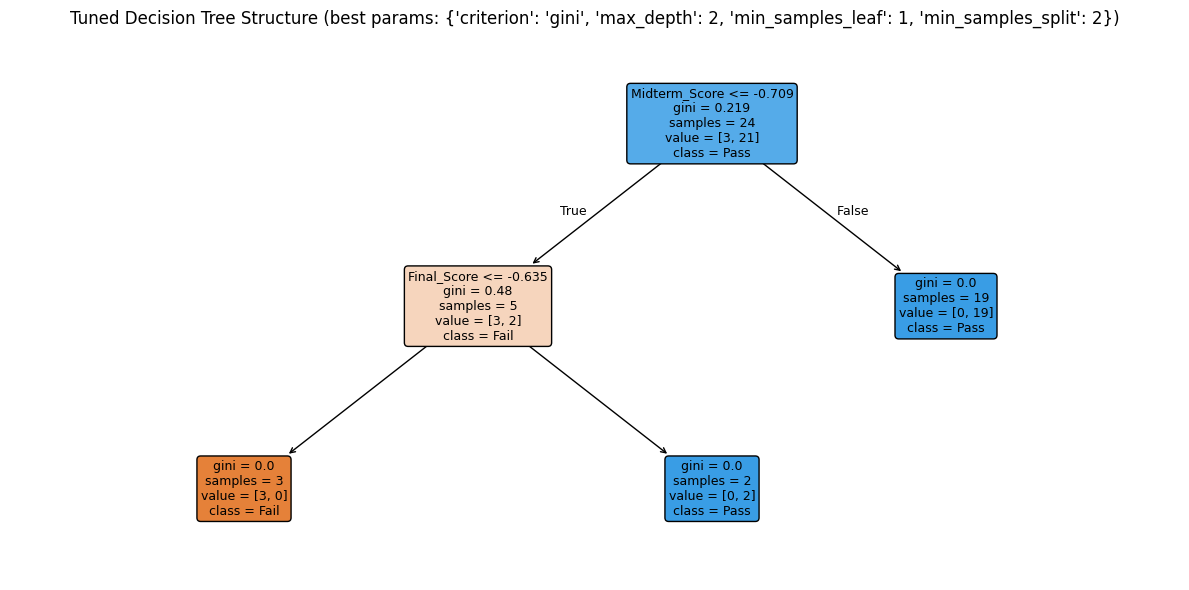

In [14]:
# Visualization 3: Tuned Decision Tree structure
plt.figure(figsize=(12, 6))
plot_tree(
    tuned_tree,
    feature_names=features,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title(f"Tuned Decision Tree Structure (best params: {grid_search.best_params_})")
plt.tight_layout()
plt.savefig("chart3_tuned_tree_structure.png")
plt.show()

## 10. Analysis

**Did GridSearchCV improve the Decision Tree?**

Looking at the comparison table above, the tuned Decision Tree's metrics
came out **identical** to the default (untuned) Decision Tree from Day 5.
GridSearchCV's best parameters turned out to closely match what the
default Decision Tree was already effectively doing on this dataset.

**This is an honest and useful result, not a failed experiment.** It tells
us something real about our dataset: with only 24 training students (and
just 3 of them being "Fail" cases), there simply isn't enough data for
different hyperparameter combinations to meaningfully separate themselves
from each other. GridSearchCV correctly searched the space we gave it and
converged on the same simple, shallow tree that already made sense for
this amount of data — a deeper or more complex tree would likely have
**overfit** to such a small training set rather than generalized better.

**How does the tuned model compare to Logistic Regression?**

Logistic Regression still performs best across Accuracy, Recall, F1 Score,
and ROC-AUC, same as we found in Day 5. Tuning the Decision Tree did not
close this gap on this particular test set.

**What did we learn from this?**

- Hyperparameter tuning is a search process — it does not automatically
  guarantee a better model, especially with very little data to learn
  from and validate against.
- Cross-validation fold count needs to be chosen with the dataset size in
  mind (we used 3 folds instead of the default 5, because of how few
  "Fail" examples we have).
- A tuned model matching a simpler default model isn't a sign that tuning
  was wasted effort — it's useful confirmation that we aren't missing an
  obviously better, more complex tree that we failed to try.
- With a larger, more balanced dataset, GridSearchCV would likely have
  more room to actually find meaningful differences between hyperparameter
  settings, and the comparison against Logistic Regression might look
  different too.